In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
df = pd.read_csv('D:\project\dataset\CSV_Files\ww-ii-data.csv')
df.head()

C:\ProgramData\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3444: DtypeWarning: Columns (7,8,18,25) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


,STA,Date,Precip,WindGustSpd,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,...,FB,FTI,ITH,PGT,TSHDSBRSGF,SD3,RHX,RHN,RVG,WTE
0,10001,7/1/1942,1.016,NaN,25.555556,22.222222,23.888889,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001,7/2/1942,0,NaN,28.888889,21.666667,25.555556,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10001,7/3/1942,2.54,NaN,26.111111,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,7/4/1942,2.54,NaN,26.666667,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10001,7/5/1942,0,NaN,26.666667,21.666667,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 31 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   STA          119040 non-null  int64  
 1   Date         119040 non-null  object 
 2   Precip       119040 non-null  object 
 3   WindGustSpd  532 non-null     float64
 4   MaxTemp      119040 non-null  float64
 5   MinTemp      119040 non-null  float64
 6   MeanTemp     119040 non-null  float64
 7   Snowfall     117877 non-null  object 
 8   PoorWeather  34237 non-null   object 
 9   YR           119040 non-null  int64  
 10  MO           119040 non-null  int64  
 11  DA           119040 non-null  int64  
 12  PRCP         117108 non-null  object 
 13  DR           533 non-null     float64
 14  SPD          532 non-null     float64
 15  MAX          118566 non-null  float64
 16  MIN          118572 non-null  float64
 17  MEA          118542 non-null  float64
 18  SNF          117877 non-

In [65]:
#Calculate percent of null for dataset
df.isnull().sum().sum()/(len(df)*len(df.columns))*100

49.70351521852237

In [4]:
(df.isnull().sum()/len(df))*100

STA              0.000000
Date             0.000000
Precip           0.000000
WindGustSpd     99.553091
MaxTemp          0.000000
MinTemp          0.000000
MeanTemp         0.000000
Snowfall         0.976983
PoorWeather     71.239079
YR               0.000000
MO               0.000000
DA               0.000000
PRCP             1.622984
DR              99.552251
SPD             99.553091
MAX              0.398185
MIN              0.393145
MEA              0.418347
SNF              0.976983
SND             95.326781
FT             100.000000
FB             100.000000
FTI            100.000000
ITH            100.000000
PGT             99.558972
TSHDSBRSGF      71.239079
SD3            100.000000
RHX            100.000000
RHN            100.000000
RVG            100.000000
WTE            100.000000
dtype: float64

In [5]:
df2=df.copy()

In [6]:
# the below dataframe contain features which are not empty
for col in df2.columns:
    percent_non_col=(df2[col].isnull().sum()/len(df2))*100
    if(100-percent_non_col<=10):
        df2.drop(col, axis=1, inplace=True)
        
#     print (col,"==>",df[col].isnull().sum())
        

In [7]:
(df2.isnull().sum()/len(df2))*100

STA             0.000000
Date            0.000000
Precip          0.000000
MaxTemp         0.000000
MinTemp         0.000000
MeanTemp        0.000000
Snowfall        0.976983
PoorWeather    71.239079
YR              0.000000
MO              0.000000
DA              0.000000
PRCP            1.622984
MAX             0.398185
MIN             0.393145
MEA             0.418347
SNF             0.976983
TSHDSBRSGF     71.239079
dtype: float64

In [8]:
df2_corr=df2.corr()

<AxesSubplot:>

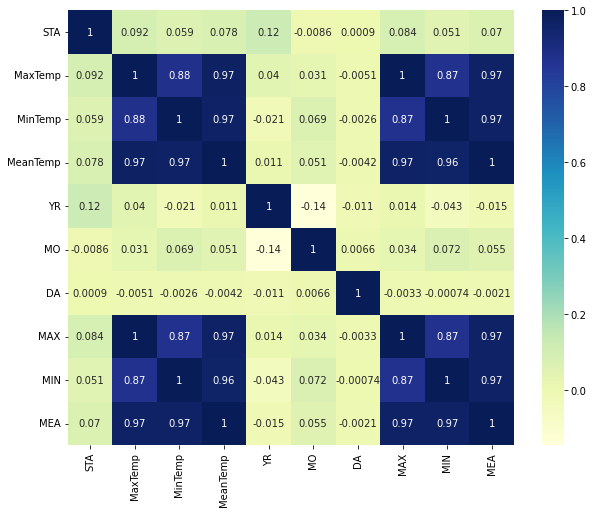

In [9]:
plt.figure(figsize=(10, 8))
sb.heatmap(df2_corr, cmap='YlGnBu', annot=True)

# The above information shows that, some of the columns are useless, but, we can select column which are vital for our models. So, STA', 'YR', 'MO', 'DA' are selctive features

In [10]:
X = df[['STA', 'YR', 'MO', 'DA']]
y = df['MaxTemp']

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=3243)

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [14]:
model.predict([X_test.iloc[100]])

array([26.32345274])

In [15]:
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import mean_absolute_error

In [17]:
mean_absolute_error(y_test, y_pred)

5.839875078654817

In [18]:
data_fig = pd.DataFrame({"Y_test": y_test , "Y_pred" : y_pred})
data_fig.head(10)

,Y_test,Y_pred
75295,18.888889,26.962023
84530,25.000000,27.422111
45772,3.888889,25.796705
91187,15.555556,27.162327
14687,28.333333,26.305683
113860,31.111111,28.746840
83424,28.888889,27.337350
18870,31.111111,26.936291
33628,37.222222,26.544252
45402,-15.555556,25.549329


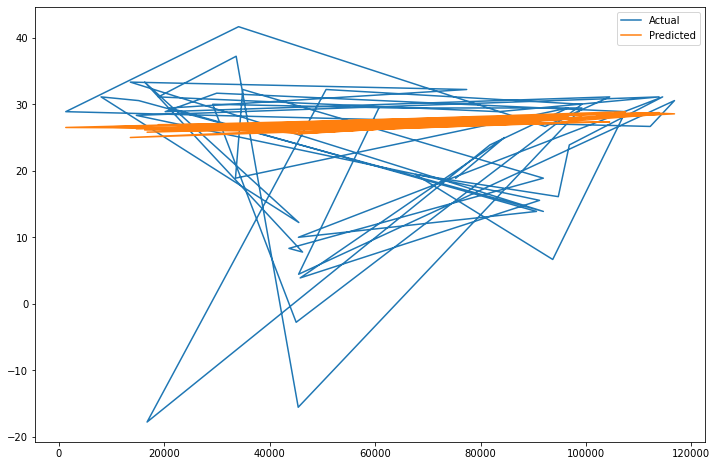

In [19]:
plt.figure(figsize=(12,8))
plt.plot(data_fig[:50])
plt.legend([ 'Actual' ,'Predicted'])

In [20]:
df.describe()

,STA,WindGustSpd,MaxTemp,MinTemp,MeanTemp,YR,MO,DA,DR,SPD,...,FT,FB,FTI,ITH,PGT,SD3,RHX,RHN,RVG,WTE
count,119040.000000,532.000000,119040.000000,119040.000000,119040.000000,119040.000000,119040.000000,119040.000000,533.000000,532.000000,...,0.0,0.0,0.0,0.0,525.000000,0.0,0.0,0.0,0.0,0.0
mean,29659.435795,37.774534,27.045111,17.789511,22.411631,43.805284,6.726016,15.797530,26.998124,20.396617,...,NaN,NaN,NaN,NaN,12.085333,NaN,NaN,NaN,NaN,NaN
std,20953.209402,10.297808,8.717817,8.334572,8.297982,1.136718,3.425561,8.794541,15.221732,5.560371,...,NaN,NaN,NaN,NaN,5.731328,NaN,NaN,NaN,NaN,NaN
min,10001.000000,18.520000,-33.333333,-38.333333,-35.555556,40.000000,1.000000,1.000000,2.000000,10.000000,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
25%,11801.000000,29.632000,25.555556,15.000000,20.555556,43.000000,4.000000,8.000000,11.000000,16.000000,...,NaN,NaN,NaN,NaN,8.500000,NaN,NaN,NaN,NaN,NaN
50%,22508.000000,37.040000,29.444444,21.111111,25.555556,44.000000,7.000000,16.000000,32.000000,20.000000,...,NaN,NaN,NaN,NaN,11.600000,NaN,NaN,NaN,NaN,NaN
75%,33501.000000,43.059000,31.666667,23.333333,27.222222,45.000000,10.000000,23.000000,34.000000,23.250000,...,NaN,NaN,NaN,NaN,15.000000,NaN,NaN,NaN,NaN,NaN
max,82506.000000,75.932000,50.000000,34.444444,40.000000,45.000000,12.000000,31.000000,78.000000,41.000000,...,NaN,NaN,NaN,NaN,23.900000,NaN,NaN,NaN,NaN,NaN


In [21]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.010647719355518337

In [22]:
df2 = df2.fillna(df2.mean())

C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_10896/239559528.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df2 = df2.fillna(df2.mean())


In [23]:
df2.head()

,STA,Date,Precip,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,MO,DA,PRCP,MAX,MIN,MEA,SNF,TSHDSBRSGF
0,10001,7/1/1942,1.016,25.555556,22.222222,23.888889,0.0,NaN,42,7,1,0.04,78.0,72.0,75.0,0.0,NaN
1,10001,7/2/1942,0,28.888889,21.666667,25.555556,0.0,NaN,42,7,2,0,84.0,71.0,78.0,0.0,NaN
2,10001,7/3/1942,2.54,26.111111,22.222222,24.444444,0.0,NaN,42,7,3,0.1,79.0,72.0,76.0,0.0,NaN
3,10001,7/4/1942,2.54,26.666667,22.222222,24.444444,0.0,NaN,42,7,4,0.1,80.0,72.0,76.0,0.0,NaN
4,10001,7/5/1942,0,26.666667,21.666667,24.444444,0.0,NaN,42,7,5,0,80.0,71.0,76.0,0.0,NaN


In [24]:
df2.isnull().sum()

STA                0
Date               0
Precip             0
MaxTemp            0
MinTemp            0
MeanTemp           0
Snowfall        1163
PoorWeather    84803
YR                 0
MO                 0
DA                 0
PRCP            1932
MAX                0
MIN                0
MEA                0
SNF             1163
TSHDSBRSGF     84803
dtype: int64

In [25]:
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        return mis_val_table_ren_columns


In [26]:
missing_values_table(df2)

,Missing Values,% of Total Values
PoorWeather,84803,71.2
TSHDSBRSGF,84803,71.2
PRCP,1932,1.6
Snowfall,1163,1.0
SNF,1163,1.0


# Remove nan and wrong value from Snowfall

In [27]:
df2['Snowfall'].unique()

array([0.0, nan, '0', '22.86', '33.02', '30.48', '2.54', '5.08', '10.16',
       '7.62', '20.32', '15.24', '17.78', '12.7', '25.4', '27.94',
       '43.18', '38.1', '45.72', '53.34', '58.42', '66.04', '76.2',
       '81.28', '73.66', '63.5', '50.8', '48.26', '60.96', '55.88',
       '35.56', '78.74', '40.64', '86.36', '83.82', '68.58', '#VALUE!',
       10.16, 7.62, 15.24, 2.54, 5.08, 12.7], dtype=object)

In [28]:
df2['Snowfall'] = pd.to_numeric(df2['Snowfall'], errors='coerce')

In [29]:
df2['Snowfall'].unique()

array([ 0.  ,   nan, 22.86, 33.02, 30.48,  2.54,  5.08, 10.16,  7.62,
       20.32, 15.24, 17.78, 12.7 , 25.4 , 27.94, 43.18, 38.1 , 45.72,
       53.34, 58.42, 66.04, 76.2 , 81.28, 73.66, 63.5 , 50.8 , 48.26,
       60.96, 55.88, 35.56, 78.74, 40.64, 86.36, 83.82, 68.58])

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Snowfall', ylabel='count'>

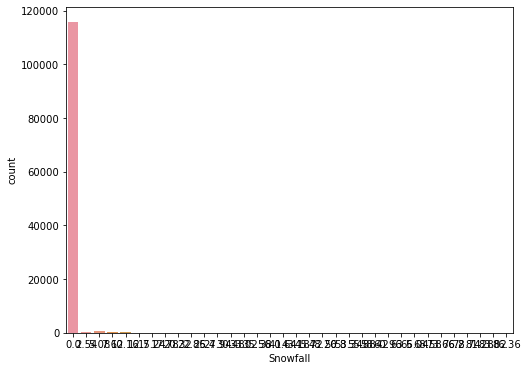

In [30]:
plt.figure(figsize = (8,6))
sb.countplot(df2['Snowfall'])

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Snowfall', ylabel='Density'>

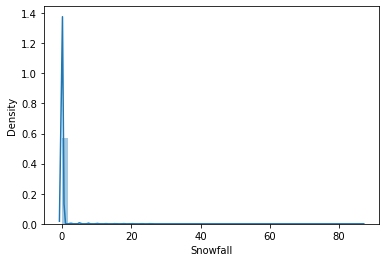

In [31]:
sb.distplot(df2['Snowfall'])

In [32]:
df2['Snowfall'].fillna(df2['Snowfall'].median(),inplace= True)

In [33]:
missing_values_table(df2)

,Missing Values,% of Total Values
PoorWeather,84803,71.2
TSHDSBRSGF,84803,71.2
PRCP,1932,1.6
SNF,1163,1.0


# Removing nan from SNF, is an object

In [34]:
df2['SNF'].unique()

array([0.0, nan, '0', '0.9', '1.3', '1.2', '0.1', '0.2', '0.4', '0.3',
       '0.8', '0.6', '0.7', '0.5', '1', '1.1', '1.7', '1.5', '1.8', '2.1',
       '2.3', '2.6', '3', '3.2', '2.9', '2.5', '2', '1.9', '2.4', '2.2',
       '1.4', '3.1', '1.6', '3.4', '3.3', '2.7', 'T', 0.4, 0.3, 0.6, 0.1,
       0.2, 0.5], dtype=object)

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='SNF', ylabel='count'>

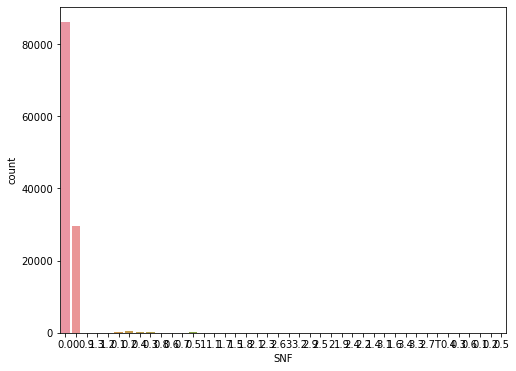

In [35]:
plt.figure(figsize = (8,6))
sb.countplot(df2['SNF'])

0.0    86090
0      29600
0.2      527
0.3      319
0.1      317
0.4      195
0.5       90
0.8       83
0.7       78
0.6       70
0.9       69
1         68
T         44
1.1       40
1.2       31
1.8       25
2         24
1.9       22
0.1       22
1.4       20
1.3       15
2.4       13
0.3       11
1.5       11
2.6       11
2.1       10
1.7       10
0.4       10
2.5        7
0.2        7
2.2        6
1.6        6
3          5
2.3        5
0.6        4
3.2        4
3.1        2
0.5        2
3.3        1
2.7        1
3.4        1
2.9        1
Name: SNF, dtype: int64


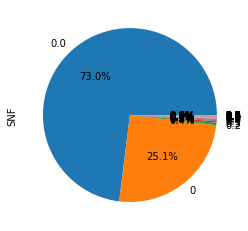

In [36]:
df2['SNF'].value_counts().plot(kind='pie',autopct='%1.1f%%')
print(df2['SNF'].value_counts())

In [37]:
# let's fill with mode value
df2['SNF']=df2['SNF'].fillna(df2['SNF'].mode()[0])

In [38]:
missing_values_table(df2)

,Missing Values,% of Total Values
PoorWeather,84803,71.2
TSHDSBRSGF,84803,71.2
PRCP,1932,1.6


# REMOVING NAN VALUES FROM PRCP

0       62335
T       16753
0.01     3389
0.02     2909
0.03     2015
        ...  
4.87        1
4.2         1
4.98        1
4.88        1
6.34        1
Name: PRCP, Length: 540, dtype: int64


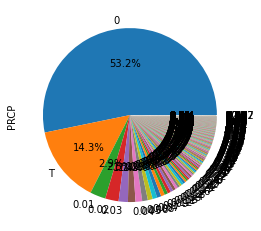

In [39]:
df2['PRCP'].value_counts().plot(kind='pie',autopct='%1.1f%%')
print(df2['PRCP'].value_counts())

In [40]:
# let's fill with mode value
df2['PRCP']=df2['PRCP'].fillna(df2['PRCP'].mode()[0])

In [41]:
missing_values_table(df2)

,Missing Values,% of Total Values
PoorWeather,84803,71.2
TSHDSBRSGF,84803,71.2


In [42]:
# we clearly see column 'PoorWeather' and 'TSHDSBRSGF' have more than 50% missing values
# so when number of missing value more than 50% of data of column, surely we can remove that column 

In [43]:
df2 = df2.drop(columns =['PoorWeather','TSHDSBRSGF'], axis=1)

In [44]:
missing_values_table(df2)

,Missing Values,% of Total Values


In [45]:
print(df2.columns)

Index(['STA', 'Date', 'Precip', 'MaxTemp', 'MinTemp', 'MeanTemp', 'Snowfall',
       'YR', 'MO', 'DA', 'PRCP', 'MAX', 'MIN', 'MEA', 'SNF'],
      dtype='object')


In [46]:
#Object or Catgorical Data

In [47]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   STA       119040 non-null  int64  
 1   Date      119040 non-null  object 
 2   Precip    119040 non-null  object 
 3   MaxTemp   119040 non-null  float64
 4   MinTemp   119040 non-null  float64
 5   MeanTemp  119040 non-null  float64
 6   Snowfall  119040 non-null  float64
 7   YR        119040 non-null  int64  
 8   MO        119040 non-null  int64  
 9   DA        119040 non-null  int64  
 10  PRCP      119040 non-null  object 
 11  MAX       119040 non-null  float64
 12  MIN       119040 non-null  float64
 13  MEA       119040 non-null  float64
 14  SNF       119040 non-null  object 
dtypes: float64(7), int64(4), object(4)
memory usage: 13.6+ MB


In [48]:
cat_data=df2.select_dtypes(exclude=np.number)
cat_data

,Date,Precip,PRCP,SNF
0,7/1/1942,1.016,0.04,0.0
1,7/2/1942,0,0,0.0
2,7/3/1942,2.54,0.1,0.0
3,7/4/1942,2.54,0.1,0.0
4,7/5/1942,0,0,0.0
...,...,...,...,...
119035,12/27/1945,0,0,0.0
119036,12/28/1945,9.906,0.39,0.0
119037,12/29/1945,0,0,0.0
119038,12/30/1945,0,0,0.0


In [49]:
df2.drop('Date', axis=1, inplace=True)

In [50]:
cat_data=df2.select_dtypes(exclude=np.number)
cat_data

,Precip,PRCP,SNF
0,1.016,0.04,0.0
1,0,0,0.0
2,2.54,0.1,0.0
3,2.54,0.1,0.0
4,0,0,0.0
...,...,...,...
119035,0,0,0.0
119036,9.906,0.39,0.0
119037,0,0,0.0
119038,0,0,0.0


In [51]:
for cat in cat_data:
    for i in range(len(df2)):
        if(df2[cat].iloc[i]!="T"):
            df2[cat].iloc[i]=float(df2[cat].iloc[i])

C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)


In [52]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 14 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   STA       119040 non-null  int64  
 1   Precip    119040 non-null  object 
 2   MaxTemp   119040 non-null  float64
 3   MinTemp   119040 non-null  float64
 4   MeanTemp  119040 non-null  float64
 5   Snowfall  119040 non-null  float64
 6   YR        119040 non-null  int64  
 7   MO        119040 non-null  int64  
 8   DA        119040 non-null  int64  
 9   PRCP      119040 non-null  object 
 10  MAX       119040 non-null  float64
 11  MIN       119040 non-null  float64
 12  MEA       119040 non-null  float64
 13  SNF       119040 non-null  object 
dtypes: float64(7), int64(4), object(3)
memory usage: 12.7+ MB


In [53]:
df2[df2['SNF']=='T']

,STA,Precip,MaxTemp,MinTemp,MeanTemp,Snowfall,YR,MO,DA,PRCP,MAX,MIN,MEA,SNF
48609,16504,0.0,-10.000000,-17.777778,-13.888889,0.0,43,1,26,0.0,14.0,0.0,7.0,T
48610,16504,0.0,-10.000000,-13.333333,-11.666667,0.0,43,1,27,0.0,14.0,8.0,11.0,T
48611,16504,1.524,-8.333333,-11.666667,-10.000000,0.0,43,1,28,0.06,17.0,11.0,14.0,T
48690,16504,T,-1.111111,-8.888889,-5.000000,0.0,43,4,17,T,30.0,16.0,23.0,T
48693,16504,T,-8.888889,-16.666667,-12.777778,0.0,43,4,20,T,16.0,2.0,9.0,T
48694,16504,0.0,-11.111111,-18.888889,-15.000000,0.0,43,4,21,0.0,12.0,-2.0,5.0,T
48695,16504,T,-11.111111,-20.000000,-15.555556,0.0,43,4,22,T,12.0,-4.0,4.0,T
48696,16504,0.0,-11.666667,-20.000000,-15.555556,0.0,43,4,23,0.0,11.0,-4.0,4.0,T
48697,16504,0.0,3.333333,-13.333333,-5.000000,0.0,43,4,24,0.0,38.0,8.0,23.0,T
48698,16504,T,0.000000,-6.666667,-3.333333,0.0,43,4,25,T,32.0,20.0,26.0,T


In [54]:
y = df2['MaxTemp']
X = df2.drop(cat_data, axis=1)
# The "T" alphabet is bizar and I have to search about that, how to delete this item.
# Addtionally when we use extra features, indeed, it helps our model works better.


In [55]:
X.isnull().sum()

STA         0
MaxTemp     0
MinTemp     0
MeanTemp    0
Snowfall    0
YR          0
MO          0
DA          0
MAX         0
MIN         0
MEA         0
dtype: int64

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=3243)

In [57]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [58]:
y_pred = model.predict(X_test)
mean_absolute_error(y_test, y_pred)

1.503477581165563e-12

In [59]:
r2_score(y_test, y_pred)

1.0

In [60]:
data_fig = pd.DataFrame({"Y_test": y_test , "Y_pred" : y_pred})
data_fig.head(10)

,Y_test,Y_pred
75295,18.888889,18.888889
84530,25.000000,25.000000
45772,3.888889,3.888889
91187,15.555556,15.555556
14687,28.333333,28.333333
113860,31.111111,31.111111
83424,28.888889,28.888889
18870,31.111111,31.111111
33628,37.222222,37.222222
45402,-15.555556,-15.555556


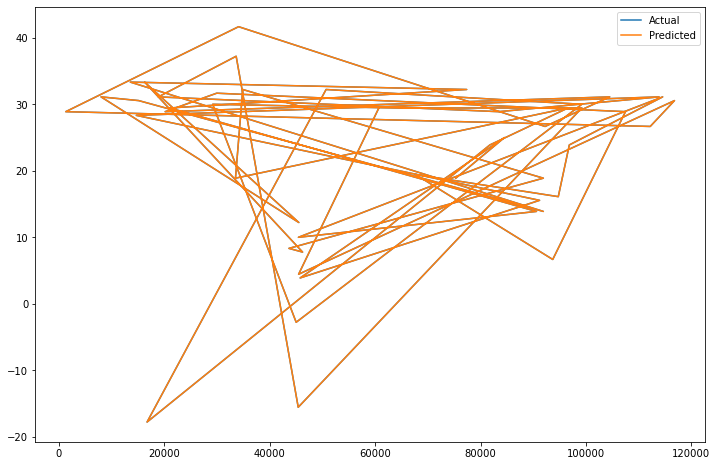

In [61]:
plt.figure(figsize=(12,8))
plt.plot(data_fig[:50])
plt.legend([ 'Actual' ,'Predicted'])